Imports


In [391]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Online Retail Dataset


## EDA


Según la página desde donde obtenemos el dataset, el mismo contiene lo siguiente:

"Este es un conjunto de datos transaccionales que contiene todas las transacciones que ocurrieron entre el 01/12/2010 y el 09/12/2011 para una tienda minorista en línea no comercial registrada y con sede en el Reino Unido. La empresa vende principalmente regalos únicos para todas las ocasiones. Muchos clientes de la empresa son mayoristas."


Y la descripción de sus columnas es:

| Nombre de Variable | Rol     | Tipo       | Descripción                                                                                                       | Unidades | Valores Faltantes |
| ------------------ | ------- | ---------- | ----------------------------------------------------------------------------------------------------------------- | -------- | ----------------- |
| InvoiceNo          | ID      | Categórica | Número entero de 6 dígitos asignado de forma única a cada transacción. Si empieza con "C", indica una cancelación | -        | no                |
| StockCode          | ID      | Categórica | Número entero de 5 dígitos asignado de forma única a cada producto                                                | -        | no                |
| Description        | Feature | Categórica | Nombre del producto                                                                                               | -        | no                |
| Quantity           | Feature | Entera     | Cantidad de cada producto (ítem) por transacción                                                                  | -        | no                |
| InvoiceDate        | Feature | Fecha      | Fecha y hora en que se generó cada transacción                                                                    | -        | no                |
| UnitPrice          | Feature | Continua   | Precio por unidad del producto                                                                                    | Libras   | no                |
| CustomerID         | Feature | Categórica | Número entero de 5 dígitos asignado de forma única a cada cliente                                                 | -        | no                |
| Country            | Feature | Categórica | Nombre del país de residencia de cada cliente                                                                     | -        | no                |


Cargamos el dataset


In [392]:
df = pd.read_excel("data/Online Retail.xlsx", sheet_name=0)

In [393]:
df.shape

(541909, 8)

Le damos una primera mirada


In [394]:
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [395]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


A primera vista vemos que hay unas **541909** filas en este dataset. Tenemos alrededor de mil registros con "Description" nula y 100mil registros con "CustomerID" nulo.


Vemos más información de los campos


In [396]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Quantity,541909.0,9.55225,-80995.0,1.0,3.0,10.0,80995.0,218.081158
InvoiceDate,541909,2011-07-04 13:34:57.156386048,2010-12-01 08:26:00,2011-03-28 11:34:00,2011-07-19 17:17:00,2011-10-19 11:27:00,2011-12-09 12:50:00,NaN
UnitPrice,541909.0,4.611114,-11062.06,1.25,2.08,4.13,38970.0,96.759853
CustomerID,406829.0,15287.69057,12346.0,13953.0,15152.0,16791.0,18287.0,1713.600303


Observamos varias cosas de este output.


1. El valor mínimo y máximo del campo "InvoiceDate" confirman el rango de fechas que maneja el dataset, según la información que nos brindaba la página cuando lo descargamos.


2. El campo "Quantity" tiene un valor mínimo que es negativo. Lo cual a primera vista no tiene sentido. Vamos a tener que investigar más.


3. El campo "UnitPrice" también tiene un valor mínimo negativo. De nuevo, vamos a tener que investigar más al respecto.


4. El campo "Quantity" y el campo "UnitPrice" tienen hasta el percentil 75 valores razonables, como ser una "Quantity" de 10 y un "UnitPrice" de 4,13. Pero el valor máximo de ambos son demasiado altos, y casi seguro que se trata de outliers.


In [397]:
df.describe(include="object").T

,count,unique,top,freq
InvoiceNo,541909,25900,573585,1114
StockCode,541909,4070,85123A,2313
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369
Country,541909,38,United Kingdom,495478


Observamos varias cosas de este output.


1. Hay 25900 valores de "InvoiceNumber" únicos, por lo que las 541909 filas del dataset son líneas de venta de un total de 25900 facturas o compras.


2. El número de "StockCode" y de "Description" no coinciden, lo cual es extraño porque a simple vista uno podría asumir que cada stock se corresponde con una descripción de un producto.


3. El país "United Kingdom" es por lejos el más frecuente en todo el dataset, con un total de 495478 filas en las que figura.


In [398]:
# Vemos algunos de los registros sin CustomerID
df[df["CustomerID"].isna()].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom
1447,536544,21790,VINTAGE SNAP CARDS,9,2010-12-01 14:32:00,1.66,NaN,United Kingdom
1448,536544,21791,VINTAGE HEADS AND TAILS CARD GAME,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1449,536544,21801,CHRISTMAS TREE DECORATION WITH BELL,10,2010-12-01 14:32:00,0.43,NaN,United Kingdom
1450,536544,21802,CHRISTMAS TREE HEART DECORATION,9,2010-12-01 14:32:00,0.43,NaN,United Kingdom
1451,536544,21803,CHRISTMAS TREE STAR DECORATION,11,2010-12-01 14:32:00,0.43,NaN,United Kingdom


Hay algunos registros inusuales, como el primero que tiene un "UnitPrice" de 0,00. Pero también hay registros que parecen legítimos, con descripciones de producto, cantidades válidades y precios razonables.


Tendremos que ver más adelante qué hacer con estos registros sin "CustomerID", puede que tengamos que descartarlos, o puede que podamos rescatar algunos.


In [399]:
# Revisamos si hay algún registro sin "CustomerID" que tenga un "InvoiceNo"
df[df["CustomerID"].isna() & df["InvoiceNo"].notna()].count()

InvoiceNo      135080
StockCode      135080
Description    133626
Quantity       135080
InvoiceDate    135080
UnitPrice      135080
CustomerID          0
Country        135080
dtype: int64

Tenemos 135080 filas que tienen un "InvoiceNo" y NO tienen un "CustomerId". Vamos a tratar de buscar otras filas con el mismo "InvoiceNo", y ver si podemos rescatar el "CustomerID" de ese modo.


In [400]:
# Guardamos los "InvoiceNo" que tienen filas sin "CustomerID"
invoices_sin_customer = df[df["CustomerID"].isna() & df["InvoiceNo"].notna()][
    "InvoiceNo"
].unique()
print(f"Número de facturas únicas sin CustomerID: {len(invoices_sin_customer)}")

# Guardamos los "InvoiceNo" que tienen filas con "CustomerID"
invoices_con_customer = df[df["CustomerID"].notna()]["InvoiceNo"].unique()

# Intersectamos los dos conjuntos de "InvoiceNo"
# para ver cuántas facturas tienen tanto filas con CustomerID como sin CustomerID
invoices_recuperables = set(invoices_sin_customer) & set(invoices_con_customer)
print(
    f"Facturas que tienen tanto filas con CustomerID como sin CustomerID: {len(invoices_recuperables)}"
)

Número de facturas únicas sin CustomerID: 3710
Facturas que tienen tanto filas con CustomerID como sin CustomerID: 0


Parece que la estrategia de recuperar "CustomerID" usando otras filas de la misma factura no va a ser posible. No hay ningún caso en el que esto suceda.


In [401]:
# Vemos los registros con cantidades negativas
df[df["Quantity"] < 0].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897.0,United Kingdom


Para esta muestra de 10 que tomamos, podemos ver que todos estos registros con cantidad negativa tienen un "CustomerID" asociado, y además, el "InvoiceNo" de todos empieza con la letra C.


Revisando la celda de arriba con la descripción de cada columna, vemos que la letra C se traduce como una transacción cancelada. Capaz eso explica la cantidad negativa.


In [402]:
# Casteamos "InvoiceNo" a string para poder analizar mejor su contenido
df["InvoiceNo"] = df["InvoiceNo"].astype(str)
df["InvoiceNo"].head(5)

0    536365
1    536365
2    536365
3    536365
4    536365
Name: InvoiceNo, dtype: object

In [403]:
# Usando una expresión regular, revisamos si hay algún registro que
# no siga el patrón de 6 dígitos con un prefijo opcional de C en "InvoiceNo"
df[~df["InvoiceNo"].str.match(r"^(C)?\d{6}$")].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299982,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,NaN,United Kingdom
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


Vemos estos 3 registros con una "Description" que da a entender que se trata de ajustes de deuda incobrable. Podría significar que fueron transacciones hechas para reflejar esa pérdida en el sistema.


No tienen importancia para nuestro análisis, pues no representan compras como tal, por lo que vamos a eliminarlos más adelante.


In [404]:
# Casteamos "StockCode" a string para poder analizar mejor su contenido
df["StockCode"] = df["StockCode"].astype(str)

In [405]:
# Usando una expresión regular, revisamos si hay algún registro que
# no siga el patrón de 5 dígitos en "StockCode"
df[~df["StockCode"].str.match(r"^\d{5}$")].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
45,536370,POST,POSTAGE,3,2010-12-01 08:45:00,18.00,12583.0,France
49,536373,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 09:02:00,2.55,17850.0,United Kingdom
51,536373,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 09:02:00,2.75,17850.0,United Kingdom
60,536373,82494L,WOODEN FRAME ANTIQUE WHITE,6,2010-12-01 09:02:00,2.55,17850.0,United Kingdom
61,536373,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 09:02:00,3.39,17850.0,United Kingdom
62,536373,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 09:02:00,3.39,17850.0,United Kingdom


Vemos que una gran cantidad de registros no responden al formato que se especifica en la descripción de la columna "StockCode". Unas **54873** filas.


Parecen transacciones válidas a primera vista. Con un "CustomerID" asociado, "UnitPrice" positivo y "Quantity" también positiva. Al menos eso se observa en la muestra de 10 que visualizamos.


In [406]:
# Eliminamos los números iniciales de "StockCode" seguido de ninguna, una o varias
# letras, para ir reduciendo el número de posibles valores únicos
df[~df["StockCode"].str.match(r"^\d{5}[A-Z]*$")]["StockCode"].unique()

array(['POST', 'D', 'C2', 'DOT', 'M', 'BANK CHARGES', '15056bl', '15056p',
       '47566b', '72349b', '84872a', '84970l', '84970s', '85039a',
       '18098c', '84509c', '84534b', '84559a', '84596e', '84884a',
       '85014a', '85014b', '85036b', '72803b', '47559b', '47591d',
       '48173c', '82494l', '84030e', '84997b', '84997c', '84997d',
       '85049a', '85049e', '85099f', '85123a', 'S', 'AMAZONFEE', '84989a',
       '15056n', '84559b', '84660c', '85114c', '72351a', '84510c',
       '84596b', '85035c', '85132a', '47570b', '84558a', 'DCGS0076',
       '35809a', '79066k', '84536b', '84968a', '84510a', '84968e',
       '85035a', '84660b', 'DCGS0003', '84796a', '72801d', '85114a',
       'gift_0001_40', 'DCGS0070', '85231b', '85114b', '85160a', 'm',
       '82613b', '82613c', '84795b', '47518f', '85035b', '84968f',
       '85049g', 'gift_0001_50', 'gift_0001_30', 'gift_0001_20', '85231g',
       '85040a', '47590b', '72807a', '72801c', '84997a', 'DCGS0055',
       'DCGS0072', 'DCGS0074'

Tal parece que las letras también pueden estar en minúscula, por lo que agregamos eso a nuestra expresión regular y volvemos a intentar


In [407]:
df[~df["StockCode"].str.match(r"^\d{5}[a-zA-Z]*$")]["StockCode"].unique()

array(['POST', 'D', 'C2', 'DOT', 'M', 'BANK CHARGES', 'S', 'AMAZONFEE',
       'DCGS0076', 'DCGS0003', 'gift_0001_40', 'DCGS0070', 'm',
       'gift_0001_50', 'gift_0001_30', 'gift_0001_20', 'DCGS0055',
       'DCGS0072', 'DCGS0074', 'DCGS0069', 'DCGS0057', 'DCGSSBOY',
       'DCGSSGIRL', 'gift_0001_10', 'PADS', 'DCGS0004', 'DCGS0073',
       'DCGS0071', 'DCGS0068', 'DCGS0067', 'DCGS0066P', 'B', 'CRUK'],
      dtype=object)

Hay muchas posibilidades. Vamos a tener que revisar uno por uno estos "StockCode" para ver si son válidos


> **Note:** El resto del análisis del campo StockCode se realizó en una notebook separada para mantener el EDA más conciso. Dicho análisis se encuentra en la carpeta `extra_analysis`.


Luego de realizar el análisis de los diferentes StockCode en el otro notebook. Las decisiones a tomar son las siguientes:


- POST: representa costos de envío. Lo vamos a excluir.
- D: representa descuentos. Lo vamos a excluir.
- C2: represneta costos de envío. Lo vamos a excluir.
- DOT: representa costos de envío. Lo vamos a excluir.
- M: representa cargas manuales. Lo vamos a excluir.
- BANK CHARGES: representa costos bancarios. Lo vamos a excluir.
- S: representa muestras gratis. Lo vamos a excluir.
- AMAZONFEE: representa tarifas de Amazon por ventas en plataforma. Lo vamos a excluir.
- ^DCGS: no sabemos qué representan. Lo vamos a excluir.
- ^gift: representa regalos. Lo vamos a excluir.
- m: representa cargas manuales. Lo vamos a excluir.
- PADS: representa compras de almohadillas. Lo vamos a CONSERVAR.
- B: representa ajustes contables. Lo vamos a excluir.
- CRUK: representa comisinones a una organización benéfica. Lo vamos a excluir.


---


### Análisis de facturas canceladas

Queremos investigar si existe una relación sistemática entre las facturas emitidas y sus cancelaciones.


Sabemos que los registros con un "InvoiceNo" que comienza con "C" corresponden a facturas canceladas. Sin embargo, sus valores negativos pueden afectar la trazabilidad de stock y montos.

Nuestra hipótesis inicial era:

> Factura → Si está mal → Factura cancelada (CXXXXX)

Pero sospechamos que el sistema realmente funciona así:

> Factura → Si está mal → Nueva factura que **revierte** montos y cantidades

Vamos a comprobar esta teoría.


In [408]:
# Separamos registros según el signo de la cantidad
ventas = df[df["Quantity"] > 0].copy()
devoluciones = df[df["Quantity"] < 0].copy()

print(f"Ventas: {len(ventas):,} registros")
print(f"Devoluciones (cancelaciones): {len(devoluciones):,} registros")

Ventas: 531,285 registros
Devoluciones (cancelaciones): 10,624 registros


#### Emparejar facturas y cancelaciones por número


Suponemos que una devolución tiene el mismo "InvoiceNo" que su factura original, pero con una "C" antepuesta.


In [409]:
# Eliminamos la "C" para intentar emparejar
devoluciones["InvoiceNo_limpio"] = devoluciones["InvoiceNo"].str.replace("C", "", n=1)

In [410]:
# Convertimos la cantidad a positiva para facilitar el match
devoluciones["Cantidad_original"] = -devoluciones["Quantity"]

In [411]:
# Intentamos hacer un merge por múltiples campos
matches_por_invoice = pd.merge(
    ventas,
    devoluciones,
    left_on=["CustomerID", "StockCode", "Quantity", "InvoiceNo"],
    right_on=["CustomerID", "StockCode", "Cantidad_original", "InvoiceNo_limpio"],
    suffixes=("_venta", "_devolución"),
)

print(f"Matches por número de factura: {len(matches_por_invoice):,}")
print(
    f"Esto representa el {len(matches_por_invoice)/len(devoluciones)*100:.1f}% de las devoluciones"
)

Matches por número de factura: 0
Esto representa el 0.0% de las devoluciones


No encontramos correspondencias. Tal vez estábamos equivocados en asumir una relación directa en el número de factura.


#### Emparejar por cliente, producto, cantidad y precio unitario


In [412]:
matches_sin_invoice = pd.merge(
    ventas,
    devoluciones,
    left_on=["CustomerID", "StockCode", "Quantity", "UnitPrice"],
    right_on=["CustomerID", "StockCode", "Cantidad_original", "UnitPrice"],
    suffixes=("_venta", "_devolución"),
)

print(f"Matches ignorando número de factura: {len(matches_sin_invoice):,}")
print(
    f"Esto representa el {len(matches_sin_invoice)/len(devoluciones)*100:.1f}% de las devoluciones"
)

Matches ignorando número de factura: 6,102
Esto representa el 57.4% de las devoluciones


Encontramos más coincidencias, aunque posiblemente muchas sean incorrectas o duplicadas.

Vamos a analizar un ejemplo.


In [413]:
matches_sin_invoice.head()

,InvoiceNo_venta,StockCode,Description_venta,Quantity_venta,InvoiceDate_venta,UnitPrice,CustomerID,Country_venta,InvoiceNo_devolución,Description_devolución,Quantity_devolución,InvoiceDate_devolución,Country_devolución,InvoiceNo_limpio,Cantidad_original
0,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,C543611,HAND WARMER RED RETROSPOT,-6,2011-02-10 14:38:00,United Kingdom,543611,6
1,536372,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 09:01:00,1.85,17850.0,United Kingdom,C543611,HAND WARMER RED RETROSPOT,-6,2011-02-10 14:38:00,United Kingdom,543611,6
2,536373,21071,VINTAGE BILLBOARD DRINK ME MUG,6,2010-12-01 09:02:00,1.06,17850.0,United Kingdom,C543611,VINTAGE BILLBOARD DRINK ME MUG,-6,2011-02-10 14:38:00,United Kingdom,543611,6
3,536373,82483,WOOD 2 DRAWER CABINET WHITE FINISH,2,2010-12-01 09:02:00,4.95,17850.0,United Kingdom,C543611,WOOD 2 DRAWER CABINET WHITE FINISH,-2,2011-02-10 14:38:00,United Kingdom,543611,2
4,536375,21071,VINTAGE BILLBOARD DRINK ME MUG,6,2010-12-01 09:32:00,1.06,17850.0,United Kingdom,C543611,VINTAGE BILLBOARD DRINK ME MUG,-6,2011-02-10 14:38:00,United Kingdom,543611,6


Hasta ahora no hemos aplicado ninguna restricción temporal. Vamos a filtrar las devoluciones que ocurren **después** de la venta correspondiente.


In [414]:
matches_con_fecha = matches_sin_invoice[
    matches_sin_invoice["InvoiceDate_venta"]
    < matches_sin_invoice["InvoiceDate_devolución"]
].copy()

print(f"Matches respetando orden temporal: {len(matches_con_fecha):,}")

Matches respetando orden temporal: 4,339


Se reduce la cantidad de matches, como esperábamos.

Ahora queremos asegurarnos de que cada devolución esté asociada a **una única venta** y viceversa.


In [415]:
# Ordenamos para priorizar devoluciones más cercanas temporalmente
matches_con_fecha = matches_con_fecha.sort_values(
    by=["InvoiceDate_devolución", "InvoiceNo_devolución"]
)

In [416]:
# Nos quedamos con el primer match por cada devolución
matches_unicos = matches_con_fecha.groupby("InvoiceNo_devolución").first().reset_index()

In [417]:
matches_unicos.head()

,InvoiceNo_devolución,InvoiceNo_venta,StockCode,Description_venta,Quantity_venta,InvoiceDate_venta,UnitPrice,CustomerID,Country_venta,Description_devolución,Quantity_devolución,InvoiceDate_devolución,Country_devolución,InvoiceNo_limpio,Cantidad_original
0,540678,540677,21667,None,1,2011-01-10 16:20:00,0.0,NaN,United Kingdom,None,-1,2011-01-10 16:21:00,United Kingdom,540678,1
1,540679,540677,21667,None,1,2011-01-10 16:20:00,0.0,NaN,United Kingdom,None,-1,2011-01-10 16:21:00,United Kingdom,540679,1
2,542572,537534,85064,CREAM SWEETHEART LETTER RACK,1,2010-12-07 11:48:00,0.0,NaN,United Kingdom,None,-1,2011-01-28 14:54:00,United Kingdom,542572,1
3,547989,547704,21621,rcvd be air temp fix for dotcom sit,100,2011-03-24 17:51:00,0.0,NaN,United Kingdom,re dotcom quick fix.,-100,2011-03-29 09:36:00,United Kingdom,547989,100
4,551455,539856,37333,"RETRO ""TEA FOR ONE""",1,2010-12-22 14:41:00,0.0,NaN,United Kingdom,None,-1,2011-04-28 16:03:00,United Kingdom,551455,1


Verificamos que no haya duplicados en las devoluciones.


In [418]:
print(matches_unicos["InvoiceNo_devolución"].duplicated().sum())

0


Lo que nos interesa ahora es tratar de entender mejor estas cancelaciones.

Cuánto tiempo pasó entre la compra y su devolución? Si pasó poco tiempo, podríamos considerar que fue una cancelación, si pasó más tiempo, podríamos considerar que fue una devolución por otro motivo, pero que la compra había sido intencionada.


In [419]:
# Podemos agregar una columna que muestre el tiempo entre la compra y la devolución
matches_unicos["Tiempo_devolucion"] = (
    matches_unicos["InvoiceDate_devolución"] - matches_unicos["InvoiceDate_venta"]
).dt.total_seconds() / 3600  # Convertimos a horas

In [420]:
matches_unicos["Tiempo_devolucion"].describe()

count    1285.000000
mean     1286.299741
std      1773.274035
min         0.016667
25%       125.016667
50%       428.650000
75%      1727.950000
max      8836.500000
Name: Tiempo_devolucion, dtype: float64

Vamos a asumir que un período de 48 horas es un lapso razonable para considerar que una compra cancelada fue no intencionada. Cualquier devolución posterior a ese plazo, consideraremos que fue una compra intencionada que por fuerzas mayores tuvo que cancelarse.


In [421]:
matches_unicos = matches_unicos[matches_unicos["Tiempo_devolucion"] <= 48]

Para terminar este análisis, armamos una lista con todos los InvoiceNo a borrar, tanto de las facturas originales como de las canceladas.


In [422]:
invoices_cancelados = (
    matches_unicos["InvoiceNo_devolución"].unique().tolist()
    + matches_unicos["InvoiceNo_venta"].unique().tolist()
)
len(invoices_cancelados)

389

Observamos un boxplot de las distintas variables. Para visualizar un poco la situación en la que se encuentran


<Axes: ylabel='Quantity'>

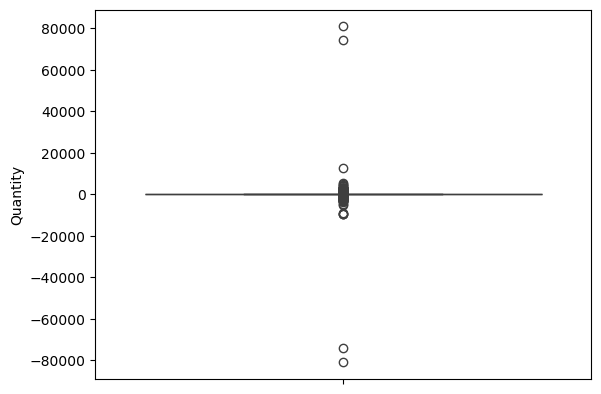

In [423]:
sns.boxplot(data=df["Quantity"])

<Axes: ylabel='UnitPrice'>

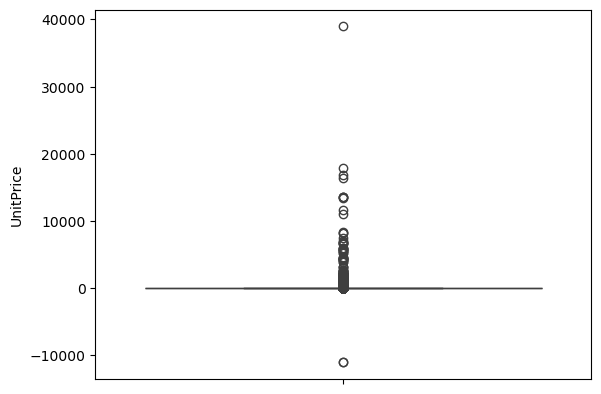

In [424]:
sns.boxplot(data=df["UnitPrice"])

Muchos outliers y valores inválidos. Luego de la limpieza volveremos a visualizar la distribución de estas variables para validar si hubo mejora.


## Data Cleaning


Vamos a limpiar el dataframe. Armamos una copia del dataframe original, para ir aplicándole máscaras e ir borrando registros.


In [425]:
clean_df = df.copy()

Lo primero que vamos a limpiar son todos aquellos registros que no respetan el formato esteblecido en el campo "InvoiceNo".


Como vimos en el EDA, los que empiezan con "C" son cancelados y los que empiezan con "A" son ajustes contables, así que los borramos.


In [426]:
clean_df = clean_df[clean_df["InvoiceNo"].str.match(r"^\d{6}$")]
clean_df.shape

(532618, 8)

Ahora vamos a lidiar con los "StockCode". Con el análisis adicional que hicimos, al final concluimos que nos ibamos a quedar únicamente con aquellos que contienen el formato indicado, y aquellos que tienen el "StockCode" "PADS".


In [427]:
stockcode_mask = clean_df["StockCode"].str.match(r"^\d{5}[a-zA-Z]*$") | clean_df[
    "StockCode"
].isin(["PADS"])

clean_df = clean_df[stockcode_mask]
clean_df.shape

(530214, 8)

También hemos concluido en el EDA que no había forma posible de recuperar aquellos registros que no cuentan con un "CustomerID", por lo que procedemos a eliminarlos.


In [428]:
clean_df = clean_df[clean_df["CustomerID"].notna()]
clean_df.shape

(396374, 8)

Con la celda de arriba se nos fueron muchos registros. Veamos si eso bastó para deshacernos de valores problemáticos como cantidades negativas o precios negativos.


In [429]:
clean_df.describe().T

,count,mean,min,25%,50%,75%,max,std
Quantity,396374.0,13.046353,1.0,2.0,6.0,12.0,80995.0,180.732689
InvoiceDate,396374,2011-07-11 00:04:48.847805440,2010-12-01 08:26:00,2011-04-07 11:16:00,2011-07-31 14:39:00,2011-10-20 14:41:00,2011-12-09 12:50:00,NaN
UnitPrice,396374.0,2.867954,0.0,1.25,1.95,3.75,649.5,4.264554
CustomerID,396374.0,15301.603824,12346.0,13975.0,15159.0,16803.0,18287.0,1709.976485


Ya no tenemos cantidades negativas ni tampoco iguales a 0.


Lo que sí tenemos son registros con un precio unitario igual a 0. Lo cual no tiene sentido para nuestro análisis.


Veamos cuántos son:


In [430]:
clean_df[clean_df["UnitPrice"] == 0].shape

(34, 8)

No son tantos, los podemos visualizar directamente


In [431]:
clean_df[clean_df["UnitPrice"] == 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-05 14:02:00,0.0,12647.0,Germany
33576,539263,22580,ADVENT CALENDAR GINGHAM SACK,4,2010-12-16 14:36:00,0.0,16560.0,United Kingdom
40089,539722,22423,REGENCY CAKESTAND 3 TIER,10,2010-12-21 13:45:00,0.0,14911.0,EIRE
47068,540372,22090,PAPER BUNTING RETROSPOT,24,2011-01-06 16:41:00,0.0,13081.0,United Kingdom
47070,540372,22553,PLASTERS IN TIN SKULLS,24,2011-01-06 16:41:00,0.0,13081.0,United Kingdom
56674,541109,22168,ORGANISER WOOD ANTIQUE WHITE,1,2011-01-13 15:10:00,0.0,15107.0,United Kingdom
86789,543599,84535B,FAIRY CAKES NOTEBOOK A6 SIZE,16,2011-02-10 13:08:00,0.0,17560.0,United Kingdom
130188,547417,22062,CERAMIC BOWL WITH LOVE HEART DESIGN,36,2011-03-23 10:25:00,0.0,13239.0,United Kingdom
139453,548318,22055,MINI CAKE STAND HANGING STRAWBERY,5,2011-03-30 12:45:00,0.0,13113.0,United Kingdom
145208,548871,22162,HEART GARLAND RUSTIC PADDED,2,2011-04-04 14:42:00,0.0,14410.0,United Kingdom


Desconocemos la razón por la cual tienen un "UnitPrice" igual a 0. No tienen un "StockCode" extraño ni nada que nos indique que se trata de un regalo o algo similar.


No sirven en nuestro análisis, vamos a descartarlos.


In [432]:
clean_df = clean_df[clean_df["UnitPrice"] > 0]

clean_df.shape

(396340, 8)

En nuestro EDA también vimos que había varias lineas de venta que resultaban canceladas eventualmente, pues encontramos registros idénticos pero con una cantidad negativa.


Como dijimos, vamos a descartar estos registros.


In [433]:
clean_df = clean_df[~clean_df["InvoiceNo"].isin(invoices_cancelados)]

clean_df.shape

(391952, 8)

Con esto damos por terminada nuestra limpieza. Veamos qué tal quedaron las variables de "Quantity" y "UnitPrice".


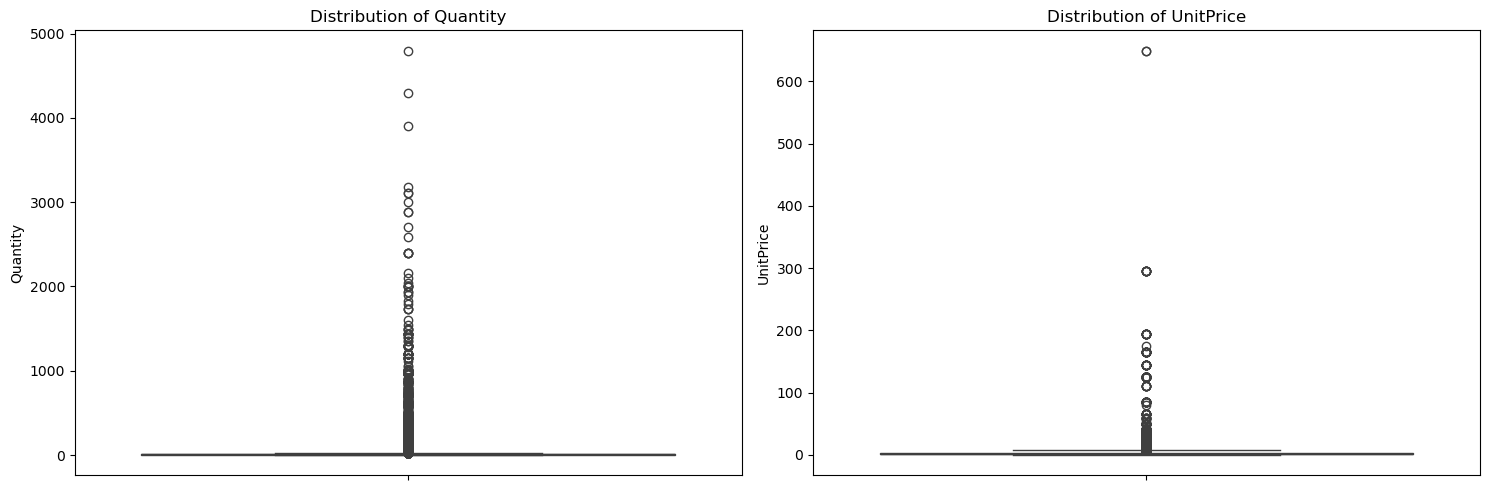

In [434]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=clean_df["Quantity"], ax=ax1)
ax1.set_title("Distribution of Quantity")
ax1.set_ylabel("Quantity")

sns.boxplot(data=clean_df["UnitPrice"], ax=ax2)
ax2.set_title("Distribution of UnitPrice")
ax2.set_ylabel("UnitPrice")

plt.tight_layout()
plt.show()

Mucho mejor. Nada de valores negativos. Y los outliers son valores mucho más razonables.

Nada de 80mil en "Quantity" o 13mil en "UnitPrice".


In [435]:
len(clean_df) / len(df)

0.7232801079147975

Nos estamos quedando con alrededor del 72% de los datos.


In [436]:
# Guardamos el dataframe limpio
clean_df.to_csv("data/cleaned_online_retail.csv", index=False)